In [1]:
# Import libraries for data analysis and visualisation
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Apply a consistent visual style
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 300

# Create a folder for saved visualisations
os.makedirs("outputs", exist_ok=True)

# Load the dataset
df = pd.read_csv("Dataset_ATS_v2.csv")

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)
df.head()

Dataset loaded successfully.
Dataset shape: (7043, 10)


,gender,SeniorCitizen,Dependents,tenure,PhoneService,MultipleLines,InternetService,Contract,MonthlyCharges,Churn
0,Female,0,No,1,No,No,DSL,Month-to-month,25,Yes
1,Male,0,No,41,Yes,No,DSL,One year,25,No
2,Female,0,Yes,52,Yes,No,DSL,Month-to-month,19,No
3,Female,0,No,1,Yes,No,DSL,One year,76,Yes
4,Male,0,No,67,Yes,No,Fiber optic,Month-to-month,51,No


## Target Variable Distribution

This section examines the overall distribution of the target variable, `Churn`. Both customer counts and percentages are calculated to determine whether the target classes are balanced.

,Customer_Count,Percentage
Churn,,
No,5174,73.46
Yes,1869,26.54


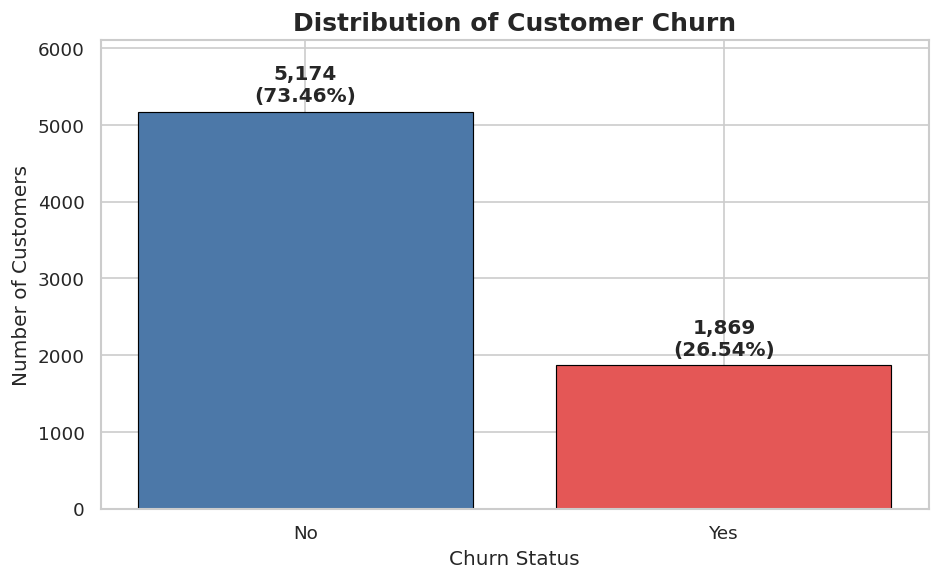

In [2]:
# Calculate churn counts and percentages
churn_counts = df["Churn"].value_counts().reindex(["No", "Yes"])
churn_percentages = (
    df["Churn"].value_counts(normalize=True)
    .reindex(["No", "Yes"])
    .mul(100)
)

# Create a summary table
churn_summary = pd.DataFrame({
    "Customer_Count": churn_counts,
    "Percentage": churn_percentages.round(2)
})

display(churn_summary)

# Create the churn distribution chart
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    churn_summary.index,
    churn_summary["Customer_Count"],
    color=["#4C78A8", "#E45756"],
    edgecolor="black",
    linewidth=0.7
)

# Add count and percentage labels above each bar
for bar, count, percentage in zip(
    bars,
    churn_summary["Customer_Count"],
    churn_summary["Percentage"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 80,
        f"{count:,}\n({percentage:.2f}%)",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

ax.set_title("Distribution of Customer Churn", fontsize=15, fontweight="bold")
ax.set_xlabel("Churn Status")
ax.set_ylabel("Number of Customers")
ax.set_ylim(0, churn_summary["Customer_Count"].max() * 1.18)

plt.tight_layout()
plt.savefig("outputs/churn_distribution.png", bbox_inches="tight")
plt.show()

## Numerical Feature Distributions by Churn Status

This section compares the distributions of customer tenure and monthly charges between churned and non-churned customers. Density-based histograms are used so that the distribution shapes remain comparable despite the unequal group sizes.

tenure                              MonthlyCharges                       \
       count   mean median    std min max          count   mean median    std   
Churn                                                                           
No      5174  37.57   38.0  24.11   0  72           5174  61.27   64.0  31.09   
Yes     1869  17.98   10.0  19.53   1  72           1869  74.43   80.0  24.67   

                
      min  max  
Churn           
No     18  119  
Yes    19  118

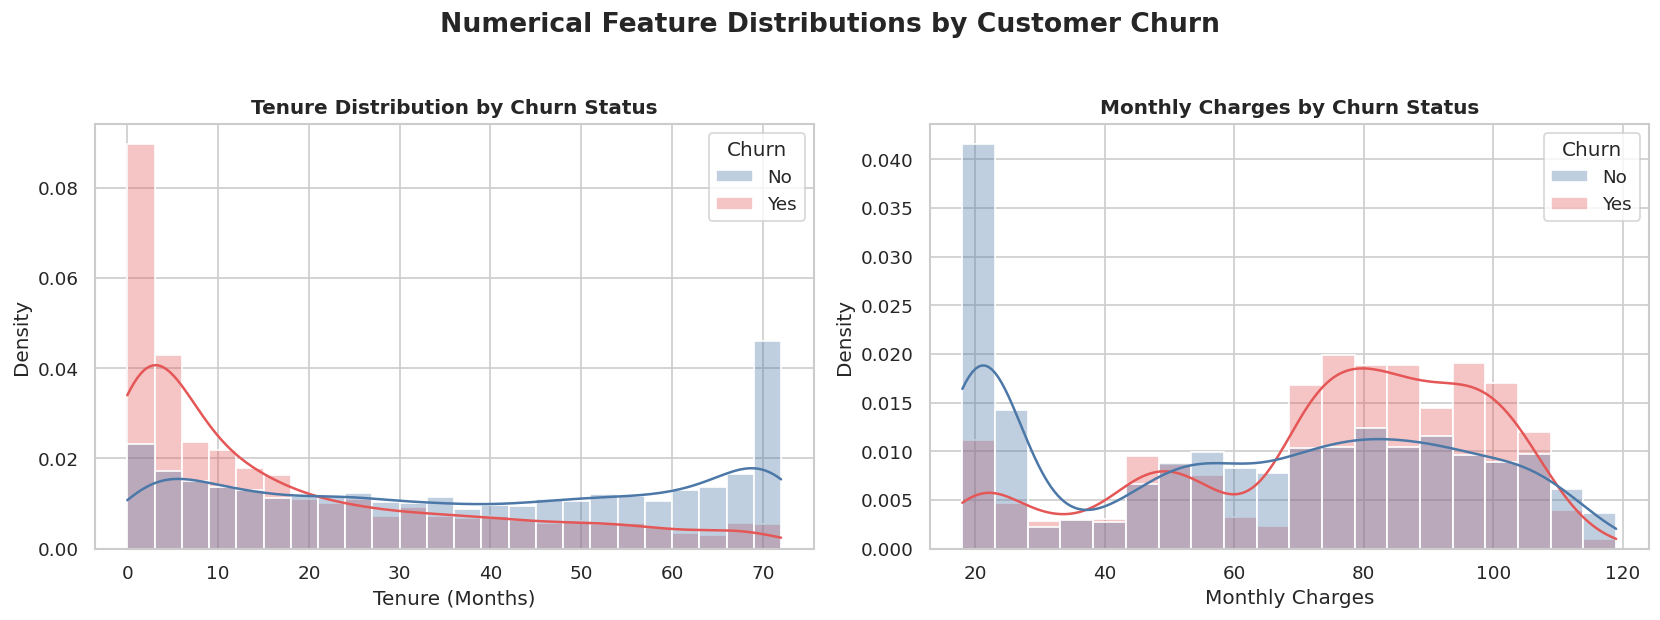

In [3]:
# Calculate descriptive statistics by churn status
numerical_summary = (
    df.groupby("Churn")[["tenure", "MonthlyCharges"]]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(2)
)

display(numerical_summary)

# Compare numerical distributions by churn status
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    data=df,
    x="tenure",
    hue="Churn",
    hue_order=["No", "Yes"],
    bins=24,
    stat="density",
    common_norm=False,
    kde=True,
    palette={"No": "#4C78A8", "Yes": "#E45756"},
    alpha=0.35,
    ax=axes[0]
)

axes[0].set_title("Tenure Distribution by Churn Status", fontweight="bold")
axes[0].set_xlabel("Tenure (Months)")
axes[0].set_ylabel("Density")

sns.histplot(
    data=df,
    x="MonthlyCharges",
    hue="Churn",
    hue_order=["No", "Yes"],
    bins=20,
    stat="density",
    common_norm=False,
    kde=True,
    palette={"No": "#4C78A8", "Yes": "#E45756"},
    alpha=0.35,
    ax=axes[1]
)

axes[1].set_title("Monthly Charges by Churn Status", fontweight="bold")
axes[1].set_xlabel("Monthly Charges")
axes[1].set_ylabel("Density")

fig.suptitle(
    "Numerical Feature Distributions by Customer Churn",
    fontsize=16,
    fontweight="bold",
    y=1.03
)

plt.tight_layout()
plt.savefig("outputs/numerical_distributions.png", bbox_inches="tight")
plt.show()

## Correlation Analysis

Pearson correlations are calculated among the numerical variables and a binary version of the churn target. `Churn` is encoded as 0 for No and 1 for Yes solely for correlation analysis.

,SeniorCitizen,tenure,MonthlyCharges,Churn_Binary
SeniorCitizen,1.000,0.017,0.220,0.151
tenure,0.017,1.000,0.248,-0.352
MonthlyCharges,0.220,0.248,1.000,0.193
Churn_Binary,0.151,-0.352,0.193,1.000


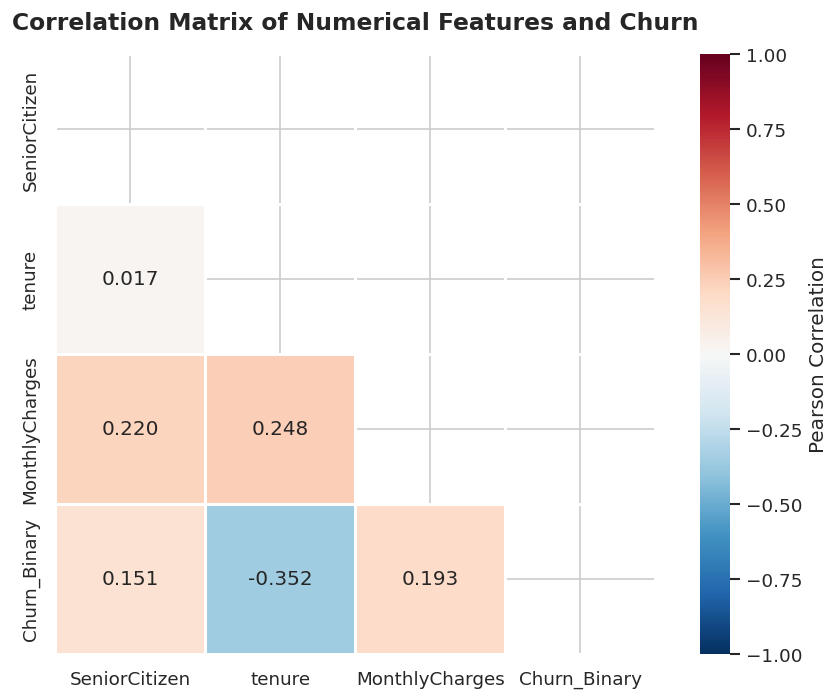

In [4]:
# Create a binary churn variable for correlation analysis
correlation_data = df[
    ["SeniorCitizen", "tenure", "MonthlyCharges"]
].copy()

correlation_data["Churn_Binary"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

# Calculate the Pearson correlation matrix
correlation_matrix = correlation_data.corr(method="pearson").round(3)

display(correlation_matrix)

# Create a mask to hide the repeated upper triangle
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

# Plot the correlation heatmap
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    mask=mask,
    annot=True,
    fmt=".3f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.8,
    cbar_kws={"label": "Pearson Correlation"}
)

plt.title(
    "Correlation Matrix of Numerical Features and Churn",
    fontsize=14,
    fontweight="bold",
    pad=15
)

plt.tight_layout()
plt.savefig("outputs/correlation_matrix.png", bbox_inches="tight")
plt.show()

## Churn Rate by Categorical Segment

Churn rates are compared across demographic, service and contract segments. Each bar reports both the churn percentage and the segment sample size.

In [5]:
# Prepare a copy for categorical churn-rate analysis
segment_df = df.copy()
segment_df["Churn_Binary"] = segment_df["Churn"].map({
    "No": 0,
    "Yes": 1
})

# Convert the binary senior-citizen field into readable labels
segment_df["SeniorCitizen"] = segment_df["SeniorCitizen"].map({
    0: "No",
    1: "Yes"
})

categorical_features = [
    "gender",
    "SeniorCitizen",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "Contract"
]

# Create a reusable function for segment summaries
def calculate_segment_summary(data, feature):
    summary = (
        data.groupby(feature, observed=False)
        .agg(
            Customer_Count=("Churn_Binary", "size"),
            Churn_Count=("Churn_Binary", "sum"),
            Churn_Rate=("Churn_Binary", "mean")
        )
        .reset_index()
    )

    summary["Churn_Rate"] = summary["Churn_Rate"] * 100
    return summary.sort_values("Churn_Rate", ascending=False)

# Display detailed churn-rate tables
segment_summaries = {}

for feature in categorical_features:
    segment_summaries[feature] = calculate_segment_summary(
        segment_df,
        feature
    )

    print(f"\nChurn analysis by {feature}:")
    display(segment_summaries[feature].round(2))


Churn analysis by gender:


,gender,Customer_Count,Churn_Count,Churn_Rate
0,Female,3488,939,26.92
1,Male,3555,930,26.16



Churn analysis by SeniorCitizen:


,SeniorCitizen,Customer_Count,Churn_Count,Churn_Rate
1,Yes,1142,476,41.68
0,No,5901,1393,23.61



Churn analysis by Dependents:


...

,MultipleLines,Customer_Count,Churn_Count,Churn_Rate
0,No,4072,1081,26.55
1,Yes,2971,788,26.52



Churn analysis by InternetService:


,InternetService,Customer_Count,Churn_Count,Churn_Rate
0,DSL,3947,1082,27.41
1,Fiber optic,3096,787,25.42



Churn analysis by Contract:


,Contract,Customer_Count,Churn_Count,Churn_Rate
0,Month-to-month,3875,1059,27.33
1,One year,1473,380,25.80
2,Two year,1695,430,25.37


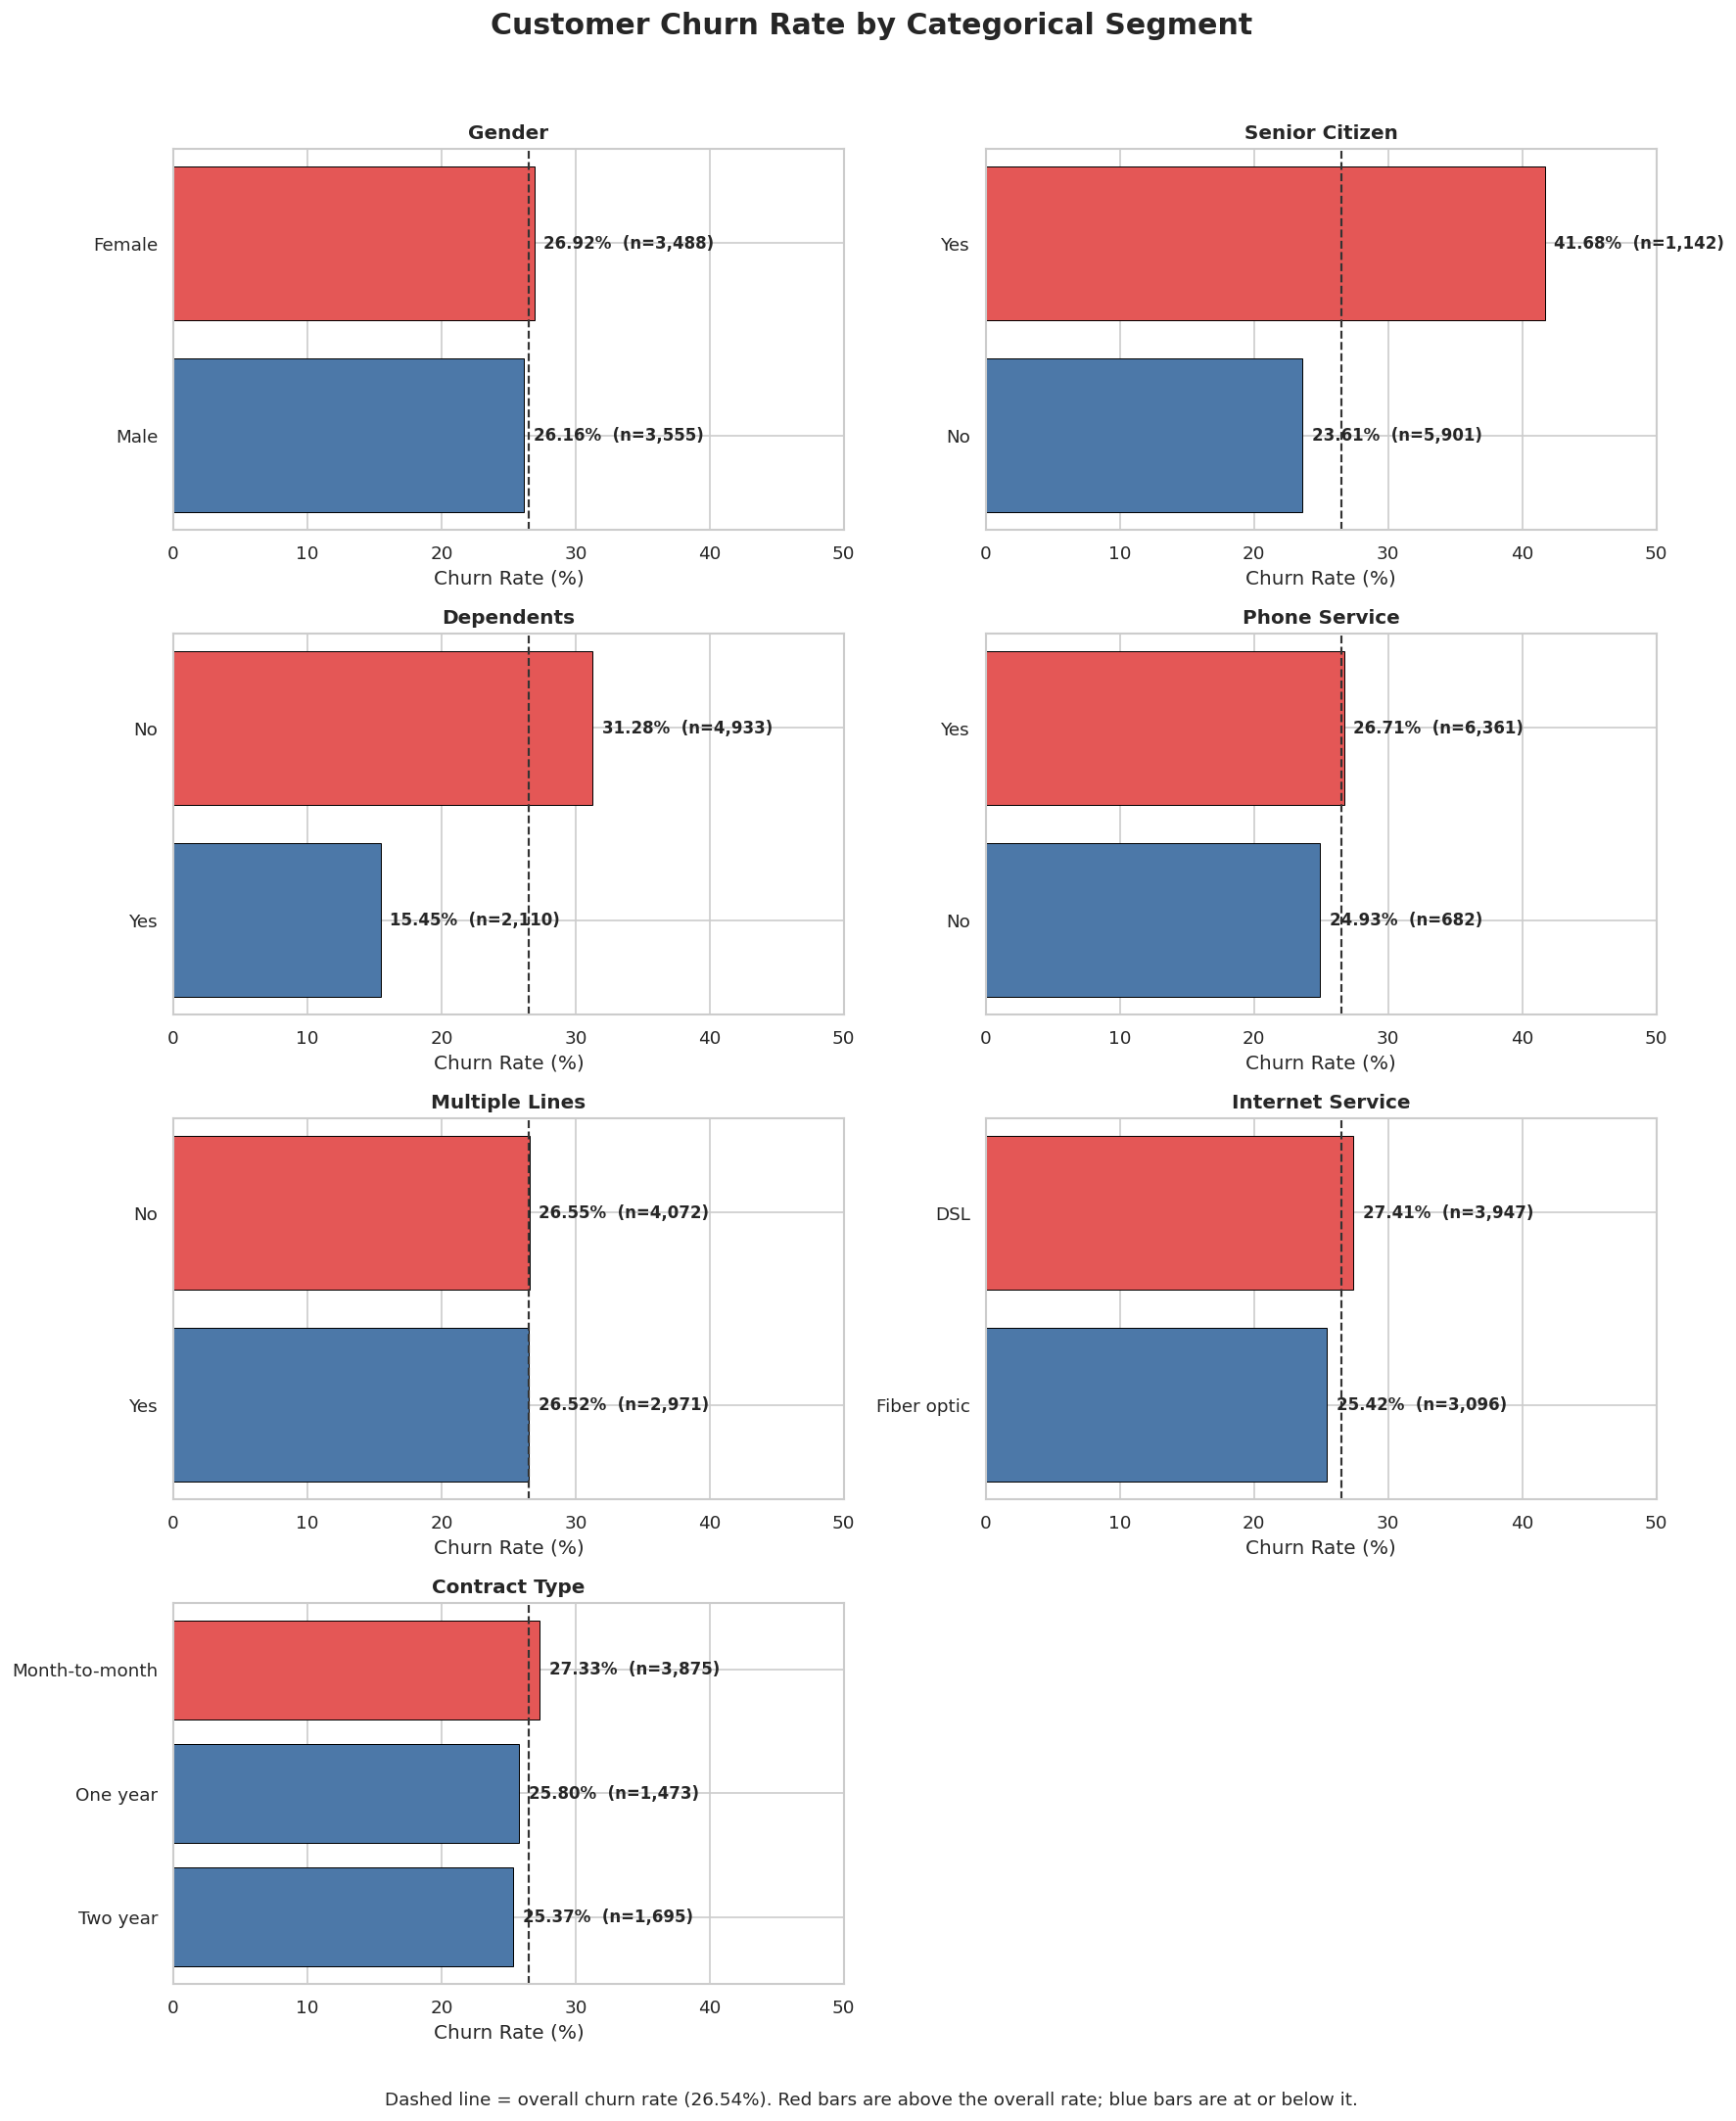

In [6]:
# Set the overall churn rate as a reference
overall_churn_rate = segment_df["Churn_Binary"].mean() * 100

# Create a multi-panel churn-rate dashboard
fig, axes = plt.subplots(4, 2, figsize=(15, 18))
axes = axes.flatten()

display_names = {
    "gender": "Gender",
    "SeniorCitizen": "Senior Citizen",
    "Dependents": "Dependents",
    "PhoneService": "Phone Service",
    "MultipleLines": "Multiple Lines",
    "InternetService": "Internet Service",
    "Contract": "Contract Type"
}

for ax, feature in zip(axes, categorical_features):
    plot_data = (
        segment_summaries[feature]
        .sort_values("Churn_Rate", ascending=True)
        .copy()
    )

    # Highlight segments above the overall churn rate
    colours = [
        "#E45756" if rate > overall_churn_rate else "#4C78A8"
        for rate in plot_data["Churn_Rate"]
    ]

    bars = ax.barh(
        plot_data[feature].astype(str),
        plot_data["Churn_Rate"],
        color=colours,
        edgecolor="black",
        linewidth=0.6
    )

    # Add the overall churn-rate reference line
    ax.axvline(
        overall_churn_rate,
        color="#333333",
        linestyle="--",
        linewidth=1.3
    )

    # Add churn rate and sample size labels
    for bar, rate, count in zip(
        bars,
        plot_data["Churn_Rate"],
        plot_data["Customer_Count"]
    ):
        ax.text(
            rate + 0.7,
            bar.get_y() + bar.get_height() / 2,
            f"{rate:.2f}%  (n={count:,})",
            va="center",
            fontsize=10,
            fontweight="bold"
        )

    ax.set_title(display_names[feature], fontweight="bold")
    ax.set_xlabel("Churn Rate (%)")
    ax.set_ylabel("")
    ax.set_xlim(0, 50)

# Remove the unused eighth panel
axes[-1].axis("off")

fig.suptitle(
    "Customer Churn Rate by Categorical Segment",
    fontsize=18,
    fontweight="bold",
    y=0.995
)

fig.text(
    0.5,
    0.005,
    (
        f"Dashed line = overall churn rate ({overall_churn_rate:.2f}%). "
        "Red bars are above the overall rate; blue bars are at or below it."
    ),
    ha="center",
    fontsize=11
)

plt.tight_layout(rect=[0, 0.025, 1, 0.975])
plt.savefig(
    "outputs/churn_rate_by_category.png",
    bbox_inches="tight"
)
plt.show()

## Key Findings and Practical Implications

1. **Overall churn:** 26.54% of customers churned, indicating a moderately imbalanced target variable.
2. **Customer lifecycle:** Churned customers had much shorter tenure, with a median of 10 months compared with 38 months among retained customers.
3. **Monthly charges:** Churned customers had higher monthly charges, with a median of 80 compared with 64 among retained customers.
4. **Strongest numerical association:** Tenure had the strongest numerical relationship with churn (`r = -0.352`).
5. **Highest-risk categorical segment:** Senior customers recorded the highest churn rate at 41.68%.
6. **Household characteristic:** Customers without dependents had a churn rate of 31.28%, compared with 15.45% among customers with dependents.
7. **Limited segment differences:** Gender, phone service, multiple lines, internet service and contract type showed relatively small differences in this dataset.

In [7]:
# Save reusable EDA summary tables
churn_summary.to_csv(
    "outputs/churn_summary.csv",
    index=True
)

numerical_summary.to_csv(
    "outputs/numerical_summary_by_churn.csv",
    index=True
)

categorical_summary_export = pd.concat(
    [
        summary.rename(columns={feature: "Category"}).assign(
            Feature=feature
        )
        for feature, summary in segment_summaries.items()
    ],
    ignore_index=True
)

categorical_summary_export = categorical_summary_export[
    [
        "Feature",
        "Category",
        "Customer_Count",
        "Churn_Count",
        "Churn_Rate"
    ]
]

categorical_summary_export.to_csv(
    "outputs/categorical_churn_summary.csv",
    index=False
)

# Verify all saved output files
print("Saved EDA outputs:")

for file_name in sorted(os.listdir("outputs")):
    file_path = os.path.join("outputs", file_name)
    file_size_kb = os.path.getsize(file_path) / 1024
    print(f"- {file_name}: {file_size_kb:.1f} KB")

Saved EDA outputs:
- categorical_churn_summary.csv: 0.7 KB
- churn_distribution.png: 105.0 KB
- churn_rate_by_category.png: 476.9 KB
- churn_summary.csv: 0.1 KB
- correlation_matrix.png: 155.6 KB
- numerical_distributions.png: 279.5 KB
- numerical_summary_by_churn.csv: 0.3 KB


In [8]:
# Compress the outputs folder for download
import shutil

shutil.make_archive(
    "eda_outputs",
    "zip",
    "outputs"
)

print("Created: eda_outputs.zip")

Created: eda_outputs.zip
